# Book recommendations

This notebook highlights recommender systems for book recommendations. The dataset is obtained from https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset/data, which contains files for the books, the users, and the ratings. 


First exploratory data analysis (EDA) is performed. Then two main approaches for recommender systems are highlighted:
1. Content-based approach
2. Collaborative filtering approach

The objective is to recommend the best fitting unread books to the users.

## Loading and pre-processing

In [1]:
import kagglehub
import os
import pandas as pd

# Download the dataset from Kaggle
path = kagglehub.dataset_download("arashnic/book-recommendation-dataset")

print("Files extracted:")
print(os.listdir(path))

Files extracted:
['classicRec.png', 'Users.csv', 'recsys_taxonomy2.png', 'Ratings.csv', 'DeepRec.png', 'Books.csv']


In [2]:
books_path = os.path.join(path, "Books.csv")

books = pd.read_csv(books_path, encoding='latin-1', low_memory=False)
books = books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']]
books.columns = ['ISBN', 'Title', 'Author', 'Year', 'Publisher', 'Image-S', 'Image-M', 'Image-L']

# Clean Year column robustly
books['Year'] = pd.to_numeric(books['Year'], errors='coerce')
books = books.dropna(subset=['Author', 'Publisher', 'Year'])
books['Year'] = books['Year'].astype(int)

books['Metadata'] = (
    books['Title'].astype(str) + ' ' +
    books['Author'].astype(str) + ' ' +
    books['Publisher'].astype(str) + ' ' +
    books['Year'].astype(str)
)


print(books.info())

<class 'pandas.core.frame.DataFrame'>
Index: 271353 entries, 0 to 271359
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   ISBN       271353 non-null  object
 1   Title      271353 non-null  object
 2   Author     271353 non-null  object
 3   Year       271353 non-null  int64 
 4   Publisher  271353 non-null  object
 5   Image-S    271353 non-null  object
 6   Image-M    271353 non-null  object
 7   Image-L    271353 non-null  object
 8   Metadata   271353 non-null  object
dtypes: int64(1), object(8)
memory usage: 20.7+ MB
None


In [3]:
ratings_path = os.path.join(path, "Ratings.csv")
ratings = pd.read_csv(ratings_path, encoding='latin-1')
ratings = ratings[['User-ID', 'ISBN', 'Book-Rating']]

print(ratings.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB
None


In [4]:
users_path = os.path.join(path, "Users.csv")
users = pd.read_csv(users_path, encoding='latin-1', on_bad_lines='skip')

print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB
None


## Exploratory Data Analysis

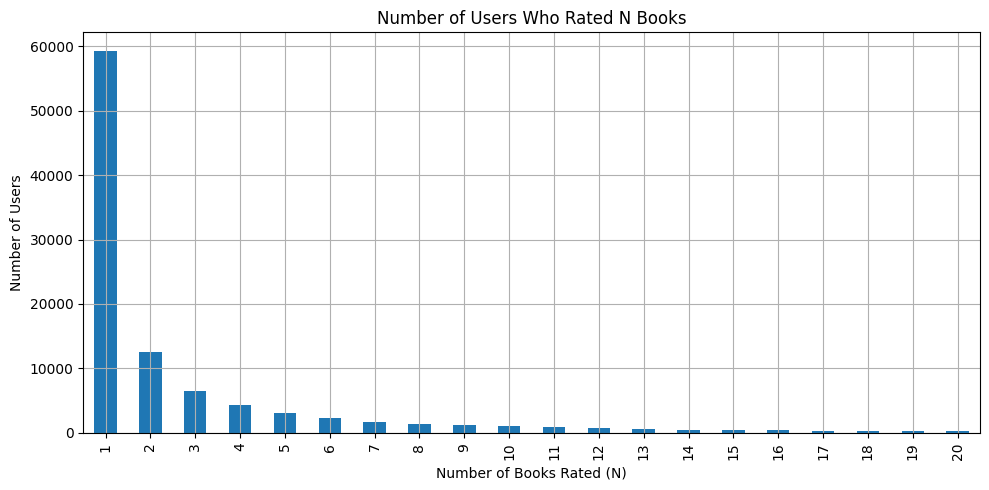

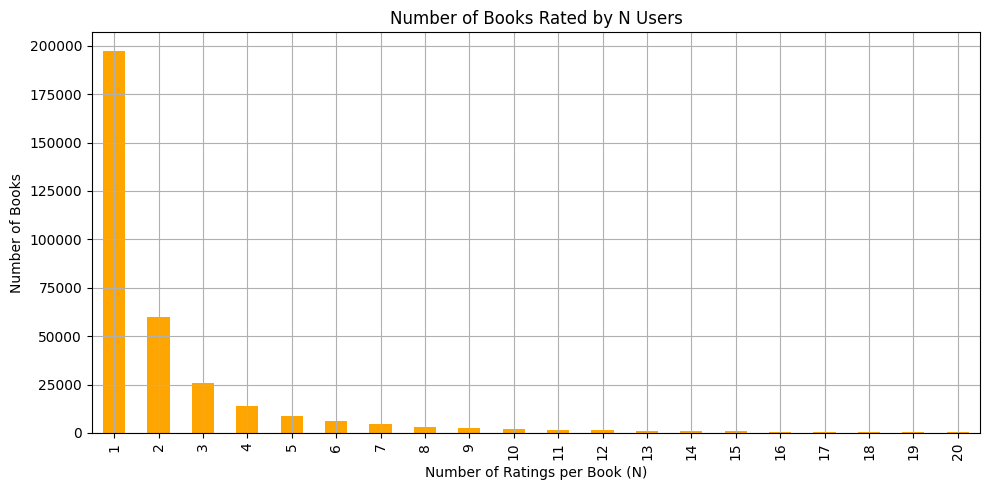

Total users: 105283
Total books: 340556
Total ratings: 1149780
Matrix sparsity: 99.9968% (i.e., 0.0032% filled)


In [5]:
import matplotlib.pyplot as plt


# 1. User rating counts
user_counts = ratings['User-ID'].value_counts()
user_hist = user_counts.value_counts().sort_index()

# 2. Book rating counts
book_counts = ratings['ISBN'].value_counts()
book_hist = book_counts.value_counts().sort_index()

# 3. Plot: How many users rated how many books
plt.figure(figsize=(10, 5))
user_hist[:20].plot(kind='bar')
plt.title("Number of Users Who Rated N Books")
plt.xlabel("Number of Books Rated (N)")
plt.ylabel("Number of Users")
plt.grid(True)
plt.tight_layout()
plt.savefig('Figures/number_of_user_who_rated_books.png', dpi=250)
plt.show()

# 4. Plot: How many books were rated by how many users
plt.figure(figsize=(10, 5))
book_hist[:20].plot(kind='bar', color='orange')
plt.title("Number of Books Rated by N Users")
plt.xlabel("Number of Ratings per Book (N)")
plt.ylabel("Number of Books")
plt.grid(True)
plt.tight_layout()
plt.savefig('Figures/number_of_books_rated_by_N_users.png', dpi=250)
plt.show()

# 5. Matrix sparsity
num_users = ratings['User-ID'].nunique()
num_books = ratings['ISBN'].nunique()
total_possible = num_users * num_books
total_ratings = len(ratings)
sparsity = 100 * (1 - total_ratings / total_possible)

print(f"Total users: {num_users}")
print(f"Total books: {num_books}")
print(f"Total ratings: {total_ratings}")
print(f"Matrix sparsity: {sparsity:.4f}% (i.e., {100 - sparsity:.4f}% filled)")

## Content based recommender systems
### 1. Tf-IDF Vectorization 

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


books_subset = books.sample(5000, random_state=42).reset_index(drop=True)

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(books_subset['Metadata'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

liked = ratings[ratings['Book-Rating'] >= 7]
liked = liked[liked['ISBN'].isin(books_subset['ISBN'])]



def recommend_to_user_from_all_likes(user_id, books_df, ratings_df, sim_matrix, top_n=1):
    # Find books user liked (rated ≥ 7)
    user_likes = ratings_df[ratings_df['User-ID'] == user_id]
    if user_likes.empty:
        return f"No ratings found for user {user_id}"

    liked_isbns = user_likes['ISBN'].values
    liked_indices = [books_df[books_df['ISBN'] == isbn].index[0]
                     for isbn in liked_isbns if isbn in books_df['ISBN'].values]

    if not liked_indices:
        return f"No liked books from user {user_id} are in the book subset"

    # Build an array of mean similarities to all liked books
    mean_sim_scores = sim_matrix[liked_indices].mean(axis=0)

    # Recommend the most similar books that the user hasn't already rated
    recommendations = []
    for idx in mean_sim_scores.argsort()[::-1]:
        recommended_book = books_df.iloc[idx]
        if recommended_book['ISBN'] not in liked_isbns:
            recommendations.append({
                'user_id': user_id,
                'based_on': [books_df.iloc[i]['Title'] for i in liked_indices],
                'recommended': recommended_book['Title'],
                'author': recommended_book['Author'],
                'fit_score': round(mean_sim_scores[idx], 3)
            })
            if len(recommendations) == top_n:
                break

    return recommendations if recommendations else f"No recommendations available for user {user_id}"

sample_user = liked['User-ID'].iloc[125]
print(recommend_to_user_from_all_likes(sample_user, books_subset, liked, cosine_sim))


# print(books_subset[books_subset['Title'] == "Chocolat"]['Author'].iloc[0])

[{'user_id': 6563, 'based_on': ['Blackberry Wine', 'Smart Women'], 'recommended': 'Chocolat', 'author': 'Joanne Harris', 'fit_score': 0.341}]


In [7]:
from IPython.display import display, HTML
from pathlib import Path

recommendation_log = []

# Adjust number of users if needed
unique_users = liked['User-ID'].unique()

for user_id in unique_users[:10000]:
    user_likes = liked[(liked['User-ID'] == user_id) & (liked['ISBN'].isin(books_subset['ISBN']))]

    if len(user_likes) < 2:
        continue

    recs = recommend_to_user_from_all_likes(user_id, books_subset, liked, cosine_sim, top_n=5)
    if isinstance(recs, list):
        for rec in recs:
            recommendation_log.append(rec)

# Now create the DataFrame
rec_df = pd.DataFrame(recommendation_log)
rec_df = rec_df.sort_values(by=['user_id', 'fit_score'], ascending=[True, False]).reset_index(drop=True)

def get_image_url(book):
    for col in ['Image-M', 'Image-L', 'Image-S']:
        url = book.get(col)
        if isinstance(url, str) and url.strip() and url.startswith('http'):
            return url
    return "https://via.placeholder.com/120x180?text=No+Image"

def display_user_summary(user_id, rec_df, books_df, ratings_df, liked_rating_threshold=8, rec_count=5, save_path=None):
    # --- Get books the user rated highly ---
    liked_books = ratings_df[
        (ratings_df['User-ID'] == user_id) &
        (ratings_df['Book-Rating'] >= liked_rating_threshold) &
        (ratings_df['ISBN'].isin(books_df['ISBN']))
    ]['ISBN'].unique()

    liked_book_objs = []
    for isbn in liked_books:
        book_row = books_df[books_df['ISBN'] == isbn]
        if not book_row.empty:
            liked_book_objs.append(book_row.iloc[0].to_dict())

    # --- Get recommendations ---
    user_recs = rec_df[rec_df['user_id'] == user_id].sort_values(by='fit_score', ascending=False).head(rec_count)

    rec_book_objs = []
    for _, row in user_recs.iterrows():
        book_row = books_df[books_df['Title'] == row['recommended']]
        if not book_row.empty:
            book_dict = book_row.iloc[0].to_dict()
            book_dict['fit_score'] = row['fit_score']
            rec_book_objs.append(book_dict)

    # --- Combine and display in one row ---
    if liked_book_objs or rec_book_objs:
        row_html = f"<h4>User {user_id}</h4><div style='display: flex; gap: 20px;'>"

        for book in liked_book_objs:
            row_html += f"""
                <div style="text-align: center; width: 120px;">
                    <img src="{get_image_url(book)}" style="height:180px;"><br>
                    <b style="font-size:0.9em;">{book['Title'][:25]}</b><br>
                    <i style="font-size:0.8em;">{book['Author'][:25]}</i><br>
                    <span style="font-size:0.75em; color:blue;">Rated</span>
                </div>
            """

        for book in rec_book_objs:
            row_html += f"""
                <div style="text-align: center; width: 120px;">
                    <img src="{get_image_url(book)}" style="height:180px;"><br>
                    <b style="font-size:0.9em;">{book['Title'][:25]}</b><br>
                    <i style="font-size:0.8em;">{book['Author'][:25]}</i><br>
                    <span style="font-size:0.75em; color:green;">Fit Score: {book['fit_score']:.3f}</span>
                </div>
            """

        row_html += "</div><hr>"
        
        if save_path:
            with open(save_path, "w", encoding="utf-8") as f:
                f.write(row_html)
                
        display(HTML(row_html))


user_best_scores = rec_df.groupby('user_id')['fit_score'].max().sort_values(ascending=False)

for i, uid in enumerate(user_best_scores.index[:5]):  # Top 5 users
    save_file = f"Figures/user_{uid}_recs.html"
    display_user_summary(uid, rec_df, books_subset, ratings_df=liked, rec_count=3, save_path=save_file)


### Remarks
In this Tf-IDF approach cosine similarity is used to measure the overlap/similarity of the metadata of the books. The metadata is a string which contains the following information:
`Title`
`Author`
`Publisher`
`Year`, with stop-words in the English language excluded.
In this recommender algorithm I took a subset of 5000 books to avoid having a huge cosine similarity matrix, and filtered out books with `rating ≥ 7`, to use the highest rated books for recommending similar books to a user. Then an aggregated `fit_score` is defined, which is the mean cosine-similarity of the books in this filtered subset and all of the liked books. This creates a score per book — how similar it is (on average) to all books the user liked. Then exclude books the user has already rated. The highest-scoring book becomes the top recommendation, and its score is returned as the `fit_score`. Above the 5 users with the highest single `fit_score` for their top recommendation are shown, to analyze why they come out on top.


As seen in the top recommendation which is "A Present for Grandfather" by
"Gertrude Chandler Warner", for User 206570, with a `fit_score`= 0.640. In itself that is a great recommendation, since the user read and rated two other books by this author. Since the author name is 3 words long, it may overlap strongly in the Metadata. The second recommended book for this user is "Scuffy the Tugboat: Based" by Gertrude Crampton with a lower score of `fit_score`= 0.152. You guessed it right, another Gertrude. All the other users also show a high same-author recommendation, especially when the user rated two books by an author, which in itself is not automatically a bad recommendation. This does however hint at Author's being a strong cause of overlapping words in the metadeta. An example of this algorithm doing well besides basing it on author is User User 243077 (3rd row). This user as their top 3 `fit_scores` well above the others, and all books are from different authors. The commonality here is that theya are all based on Star Trek, making this a great and intuitively logical prediction.


Tf-IDF bases its scores on lexical similarity, seeing if these literal words are mentioned elsewhere (which is why User 206570 got a book recommended by another Gertrude, after reading two from a different Gertrude). However, this approach does not take into account semantic similarity, i.e. how similar books are in terms of meaning. For example these two books:
1. “Thinking, Fast and Slow”
2. “The Power of Habit: Why We Do What We Do in Life and Business”
These are both popular psycology books as they explore how humans think, make decisions, form patterns. They are very similar in meaning. However, if we look at how many overlap the titles have after removing stopwords, we can see they are completely lexically disjoint. Therefore a pre-trained sentence transformer model is used in the next section to try and capture semantic similarity between books.

### 2. Sentence Transformer (Pretrained model)

In [16]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

semantic_vectors = model.encode(books_subset['Metadata'], show_progress_bar=True)
cosine_sim_semantic = cosine_similarity(semantic_vectors)
recommend_to_user_from_all_likes(user_id, books_subset, liked, cosine_sim_semantic, top_n=5)

recommendation_log_semantic = []

unique_users = liked['User-ID'].unique()

for user_id in unique_users[:10000]:  # or fewer for testing
    user_likes = liked[(liked['User-ID'] == user_id) & (liked['ISBN'].isin(books_subset['ISBN']))]
    
    if len(user_likes) < 2:
        continue

    # Swap in the semantic similarity matrix
    recs = recommend_to_user_from_all_likes(user_id, books_subset, liked, cosine_sim_semantic, top_n=5)
    if isinstance(recs, list):
        for rec in recs:
            recommendation_log_semantic.append(rec)

# Create semantic recommendation DataFrame
rec_df_semantic = pd.DataFrame(recommendation_log_semantic)
rec_df_semantic = rec_df_semantic.sort_values(by=['user_id', 'fit_score'], ascending=[True, False]).reset_index(drop=True)

user_best_scores = rec_df_semantic.groupby('user_id')['fit_score'].max().sort_values(ascending=False)

for uid in user_best_scores.index[:5]:  # top 5 users
    save_file = f"Figures/user_{uid}_transformer_recs.html"
    display_user_summary(uid, rec_df_semantic, books_subset, ratings_df=liked, rec_count=3, save_path=save_file)


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

### Remarks
At first site these recommendations are quite different from the Tf-IDF recommendation. Overall the second and third recommendation have higher scores, meaning this algorithm does well as a general recommendation system, also striking a good balance between same author and different author.
For the first displayed User which is the same one as before (User 206570) the other 'Gertrude' book is no longer there, and the 2nd and 3rd book have a higher Cosine similarity than before. Something else that becomes clear is that several German readers showed up, with recommended books with high `fit_score`, all having in common that they are German. This is likely because stop-words were removed for the English language, not accounting for foreign language stop-words such as "auf" and "du" in German. This reveals to my surprise that this dataset contains books in other languages, which ideally need to be accounted for in their stop-words, or filtered out.


Overall this transformer model seems to do well as a general recommender, appropriately accounting for semantic similarity.

## Collaborative Filtering approach

### 1. KNNBasic from the surprise library

In [9]:
from surprise import Dataset, Reader
from surprise import KNNBasic
from surprise.model_selection import train_test_split
from surprise import accuracy
from collections import defaultdict

top_5_users = list(user_best_scores.index[:5])

ratings_filtered = liked[['User-ID', 'ISBN', 'Book-Rating']].copy()
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(ratings_filtered, reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

sim_options = {
    'name': 'pearson',
    'user_based': True
}


model_knn = KNNBasic(k=30, sim_options=sim_options)
model_knn.fit(trainset)
model_knn.trainset = trainset 

Computing the pearson similarity matrix...
Done computing similarity matrix.


In [10]:
def get_top_recs_for_user(user_id, model, books_df, ratings_df, n=3):
    rated_isbns = ratings_df[ratings_df['User-ID'] == user_id]['ISBN'].values
    all_isbns = books_df['ISBN'].unique()
    unseen_isbns = [isbn for isbn in all_isbns if isbn not in rated_isbns]

    predictions = [model.predict(str(user_id), str(isbn)) for isbn in unseen_isbns]
    top_preds = sorted(predictions, key=lambda x: x.est, reverse=True)[:n]

    recs = []
    for pred in top_preds:
        title = books_df[books_df['ISBN'] == pred.iid]['Title'].values
        title = title[0] if len(title) > 0 else pred.iid
        recs.append((title, pred.est))
    return recs


print("📚 KNN-Based Recommendations for Same Top 5 Users:\n")

for user_id in top_5_users:
    print(f"🔸 User {user_id}")
    recs = get_top_recs_for_user(user_id, model_knn, books_subset, liked, n=3)
    for title, score in recs:
        print(f"  - {title} (Predicted Rating: {score:.2f})")
    print()

📚 KNN-Based Recommendations for Same Top 5 Users:

🔸 User 206570
  - The Penguin Encyclopaedia of Horror and the Supernatural (Predicted Rating: 8.47)
  - Sisters of Cain: A Seneca Falls Civil War Mystery (Predicted Rating: 8.47)
  - The Altar of the Dead (Predicted Rating: 8.47)

🔸 User 276538
  - The Penguin Encyclopaedia of Horror and the Supernatural (Predicted Rating: 8.47)
  - Sisters of Cain: A Seneca Falls Civil War Mystery (Predicted Rating: 8.47)
  - The Altar of the Dead (Predicted Rating: 8.47)

🔸 User 32440
  - The Penguin Encyclopaedia of Horror and the Supernatural (Predicted Rating: 8.47)
  - Sisters of Cain: A Seneca Falls Civil War Mystery (Predicted Rating: 8.47)
  - The Altar of the Dead (Predicted Rating: 8.47)

🔸 User 142026
  - The Penguin Encyclopaedia of Horror and the Supernatural (Predicted Rating: 8.47)
  - Sisters of Cain: A Seneca Falls Civil War Mystery (Predicted Rating: 8.47)
  - The Altar of the Dead (Predicted Rating: 8.47)

🔸 User 118625
  - The Peng

### 2. NMF

In [11]:
from surprise import NMF
from collections import Counter

model_nmf = NMF(n_factors=15, random_state=42)
model_nmf.fit(trainset)
model_nmf.trainset = trainset

print("📚 NMF-Based Recommendations for Top 5 Users:\n")

for user_id in top_5_users:
    print(f"🔸 User {user_id}")
    recs = get_top_recs_for_user(user_id, model_nmf, books_subset, liked, n=3)
    for title, score in recs:
        print(f"  - {title} (Predicted Rating: {score:.2f})")
    print()
    


📚 NMF-Based Recommendations for Top 5 Users:

🔸 User 206570
  - The Penguin Encyclopaedia of Horror and the Supernatural (Predicted Rating: 8.47)
  - Sisters of Cain: A Seneca Falls Civil War Mystery (Predicted Rating: 8.47)
  - The Altar of the Dead (Predicted Rating: 8.47)

🔸 User 276538
  - The Penguin Encyclopaedia of Horror and the Supernatural (Predicted Rating: 8.47)
  - Sisters of Cain: A Seneca Falls Civil War Mystery (Predicted Rating: 8.47)
  - The Altar of the Dead (Predicted Rating: 8.47)

🔸 User 32440
  - The Penguin Encyclopaedia of Horror and the Supernatural (Predicted Rating: 8.47)
  - Sisters of Cain: A Seneca Falls Civil War Mystery (Predicted Rating: 8.47)
  - The Altar of the Dead (Predicted Rating: 8.47)

🔸 User 142026
  - The Penguin Encyclopaedia of Horror and the Supernatural (Predicted Rating: 8.47)
  - Sisters of Cain: A Seneca Falls Civil War Mystery (Predicted Rating: 8.47)
  - The Altar of the Dead (Predicted Rating: 8.47)

🔸 User 118625
  - The Penguin E

### Remarks
For KNNBasic as well as NMF based Collaborative Filter recommenders, all users seem to get the same books recommended with identical rating. That means something strange is going on. Therefore I'll try to diagnose what's happening
### Diagnostics

In [12]:
top_books = [
    "The Penguin Encyclopaedia of Horror and the Supernatural",
    "Sisters of Cain: A Seneca Falls Civil War Mystery",
    "The Altar of the Dead"
]

for user_id in top_5_users:
    print(f"\nUser {user_id} has rated:")
    for title in top_books:
        isbn_match = books_subset[books_subset['Title'] == title]['ISBN'].values
        rated = liked[(liked['User-ID'] == user_id) & (liked['ISBN'].isin(isbn_match))]
        if not rated.empty:
            print(f" - {title} ✅ (already rated)")
        else:
            print(f" - {title} ❌ (unrated)")

print()
            
# Count how often these books appear in the training ratings
for title in top_books:
    isbns = books_subset[books_subset['Title'] == title]['ISBN'].values
    count = liked[liked['ISBN'].isin(isbns)].shape[0]
    print(f"{title}: {count} ratings")


print()
# For each top user, get their rated ISBNs
user_rated_isbns = [set(liked[liked['User-ID'] == uid]['ISBN']) for uid in top_5_users]

# Flatten and count overlaps
isbn_counter = Counter(isbn for s in user_rated_isbns for isbn in s)

# Books rated by 2+ users
shared_books = [isbn for isbn, count in isbn_counter.items() if count >= 2]

print(f"Books rated by ≥2 of the top 5 users: {len(shared_books)}")

# Optionally, print a few of them
shared_titles = books_subset[books_subset['ISBN'].isin(shared_books)]['Title'].unique()
print(f"Examples: {shared_titles[:5]}")


User 206570 has rated:
 - The Penguin Encyclopaedia of Horror and the Supernatural ❌ (unrated)
 - Sisters of Cain: A Seneca Falls Civil War Mystery ❌ (unrated)
 - The Altar of the Dead ❌ (unrated)

User 276538 has rated:
 - The Penguin Encyclopaedia of Horror and the Supernatural ❌ (unrated)
 - Sisters of Cain: A Seneca Falls Civil War Mystery ❌ (unrated)
 - The Altar of the Dead ❌ (unrated)

User 32440 has rated:
 - The Penguin Encyclopaedia of Horror and the Supernatural ❌ (unrated)
 - Sisters of Cain: A Seneca Falls Civil War Mystery ❌ (unrated)
 - The Altar of the Dead ❌ (unrated)

User 142026 has rated:
 - The Penguin Encyclopaedia of Horror and the Supernatural ❌ (unrated)
 - Sisters of Cain: A Seneca Falls Civil War Mystery ❌ (unrated)
 - The Altar of the Dead ❌ (unrated)

User 118625 has rated:
 - The Penguin Encyclopaedia of Horror and the Supernatural ❌ (unrated)
 - Sisters of Cain: A Seneca Falls Civil War Mystery ❌ (unrated)
 - The Altar of the Dead ❌ (unrated)

The Pengui

In [13]:
from surprise import Dataset, Reader, NMF
from surprise.model_selection import train_test_split
import pandas as pd

# Relaxed filtering: include ratings ≥ 7
liked_nmf = liked[liked['Book-Rating'] >= 7].copy()

# Keep books with ≥ 3 ratings
book_counts = liked_nmf['ISBN'].value_counts()
popular_books = book_counts[book_counts >= 3].index
liked_nmf = liked_nmf[liked_nmf['ISBN'].isin(popular_books)]

# Keep users with ≥ 3 ratings
user_counts = liked_nmf['User-ID'].value_counts()
active_users = user_counts[user_counts >= 3].index
liked_nmf = liked_nmf[liked_nmf['User-ID'].isin(active_users)]

# Load into surprise
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(liked_nmf[['User-ID', 'ISBN', 'Book-Rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train NMF model
model_nmf = NMF(n_factors=15, random_state=42)
model_nmf.fit(trainset)
model_nmf.trainset = trainset  # required for predict()

# Recommendation function
def get_top_recs_for_user(user_id, model, books_df, ratings_df, n=3):
    rated_isbns = ratings_df[ratings_df['User-ID'] == user_id]['ISBN'].values
    all_isbns = books_df['ISBN'].unique()
    unseen_isbns = [isbn for isbn in all_isbns if isbn not in rated_isbns]

    predictions = [model.predict(str(user_id), str(isbn)) for isbn in unseen_isbns]
    top_preds = sorted(predictions, key=lambda x: x.est, reverse=True)[:n]

    recs = []
    for pred in top_preds:
        title = books_df[books_df['ISBN'] == pred.iid]['Title'].values
        title = title[0] if len(title) > 0 else pred.iid
        recs.append((title, pred.est))
    return recs

# Pick top 5 users from the new filtered dataset
top_5_users = liked_nmf['User-ID'].value_counts().index[:5]

# Show recommendations
print("📚 NMF-Based Recommendations (Relaxed Filters):\n")
for user_id in top_5_users:
    print(f"🔸 User {user_id}")
    recs = get_top_recs_for_user(user_id, model_nmf, books_subset, liked_nmf, n=3)
    for title, score in recs:
        print(f"  - {title} (Predicted Rating: {score:.2f})")
    print()


📚 NMF-Based Recommendations (Relaxed Filters):

🔸 User 11676
  - The Penguin Encyclopaedia of Horror and the Supernatural (Predicted Rating: 8.51)
  - Sisters of Cain: A Seneca Falls Civil War Mystery (Predicted Rating: 8.51)
  - The Altar of the Dead (Predicted Rating: 8.51)

🔸 User 98391
  - The Penguin Encyclopaedia of Horror and the Supernatural (Predicted Rating: 8.51)
  - Sisters of Cain: A Seneca Falls Civil War Mystery (Predicted Rating: 8.51)
  - The Altar of the Dead (Predicted Rating: 8.51)

🔸 User 153662
  - The Penguin Encyclopaedia of Horror and the Supernatural (Predicted Rating: 8.51)
  - Sisters of Cain: A Seneca Falls Civil War Mystery (Predicted Rating: 8.51)
  - The Altar of the Dead (Predicted Rating: 8.51)

🔸 User 37950
  - The Penguin Encyclopaedia of Horror and the Supernatural (Predicted Rating: 8.51)
  - Sisters of Cain: A Seneca Falls Civil War Mystery (Predicted Rating: 8.51)
  - The Altar of the Dead (Predicted Rating: 8.51)

🔸 User 135149
  - The Penguin E

In [14]:
print(liked['Book-Rating'].value_counts().sort_index())

top_books = [
    "The Penguin Encyclopaedia of Horror and the Supernatural",
    "Sisters of Cain: A Seneca Falls Civil War Mystery",
    "The Altar of the Dead"
]

# Count how often these books appear in the training ratings
for title in top_books:
    isbns = books_subset[books_subset['Title'] == title]['ISBN'].values
    count = liked[liked['ISBN'].isin(isbns)].shape[0]
    print(f"{title}: {count} ratings")

for user_id in top_5_users:
    print(f"\nUser {user_id} has rated:")
    for title in top_books:
        isbn_match = books_subset[books_subset['Title'] == title]['ISBN'].values
        rated = liked[(liked['User-ID'] == user_id) & (liked['ISBN'].isin(isbn_match))]
        if not rated.empty:
            print(f" - {title} ✅ (already rated)")
        else:
            print(f" - {title} ❌ (unrated)")

# For each top user, get their rated ISBNs
user_rated_isbns = [set(liked[liked['User-ID'] == uid]['ISBN']) for uid in top_5_users]

# Flatten and count overlaps
isbn_counter = Counter(isbn for s in user_rated_isbns for isbn in s)

# Books rated by 2+ users
shared_books = [isbn for isbn, count in isbn_counter.items() if count >= 2]

print(f"Books rated by ≥2 of the top 5 users: {len(shared_books)}")

# Optionally, print a few of them
shared_titles = books_subset[books_subset['ISBN'].isin(shared_books)]['Title'].unique()
print(f"Examples: {shared_titles[:5]}")

Book-Rating
7     1210
8     1634
9     1101
10    1279
Name: count, dtype: int64
The Penguin Encyclopaedia of Horror and the Supernatural: 0 ratings
Sisters of Cain: A Seneca Falls Civil War Mystery: 0 ratings
The Altar of the Dead: 0 ratings

User 11676 has rated:
 - The Penguin Encyclopaedia of Horror and the Supernatural ❌ (unrated)
 - Sisters of Cain: A Seneca Falls Civil War Mystery ❌ (unrated)
 - The Altar of the Dead ❌ (unrated)

User 98391 has rated:
 - The Penguin Encyclopaedia of Horror and the Supernatural ❌ (unrated)
 - Sisters of Cain: A Seneca Falls Civil War Mystery ❌ (unrated)
 - The Altar of the Dead ❌ (unrated)

User 153662 has rated:
 - The Penguin Encyclopaedia of Horror and the Supernatural ❌ (unrated)
 - Sisters of Cain: A Seneca Falls Civil War Mystery ❌ (unrated)
 - The Altar of the Dead ❌ (unrated)

User 37950 has rated:
 - The Penguin Encyclopaedia of Horror and the Supernatural ❌ (unrated)
 - Sisters of Cain: A Seneca Falls Civil War Mystery ❌ (unrated)
 - T

This shows that none of the recommended books were rated by the specific user, which means they were unseen by them, which is good. However, it appears that these books were not rated at all (given the subset and filtering). Collaborative filtering can’t learn from unrated items. CF (especially KNN and NMF) requires interactions to form user-user or item-item similarities. If a book has 0 ratings, it's like it doesn't exist to the model. Predictions fall back to global averages or default behavior (e.g. 8.47). If those unrated books are in the candidate list, the model picks them blindly. They might have a default similarity to all users (especially in models that don’t regularize enough).


We can refer back to the origial data and take some extra filtering measures to try and find books that were rated, by users that have also rated several otherbooks to counter sparsity, as seen below.

In [15]:
from surprise import Dataset, Reader, KNNBasic
from surprise.model_selection import train_test_split
import pandas as pd

# Filter for explicit ratings only
ratings_explicit = ratings[ratings['Book-Rating'] >= 1].copy()

# Reduce sparsity: Keep books with ≥5 ratings and users with ≥5 ratings
book_counts = ratings_explicit['ISBN'].value_counts()
popular_books = book_counts[book_counts >= 5].index
filtered = ratings_explicit[ratings_explicit['ISBN'].isin(popular_books)]

user_counts = filtered['User-ID'].value_counts()
active_users = user_counts[user_counts >= 5].index
filtered = filtered[filtered['User-ID'].isin(active_users)]

# Prepare Surprise dataset
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(filtered[['User-ID', 'ISBN', 'Book-Rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train KNNBasic (item-based)
sim_options = {'name': 'cosine', 'user_based': False}
model_knn = KNNBasic(sim_options=sim_options)
model_knn.fit(trainset)
model_knn.trainset = trainset

unique_user_ids = filtered['User-ID'].drop_duplicates().tolist()[:5]

for user_id in unique_user_ids:
    user_rated = filtered[filtered['User-ID'] == user_id]['ISBN'].tolist()
    unseen_books = [isbn for isbn in filtered['ISBN'].unique() if isbn not in user_rated]

    predictions = [model_knn.predict(str(user_id), str(isbn)) for isbn in unseen_books]
    top_preds = sorted(predictions, key=lambda x: x.est, reverse=True)[:3]

    print(f"🔸 User {user_id}")
    for pred in top_preds:
        book_info = books[books['ISBN'] == pred.iid]
        title = book_info['Title'].values[0] if not book_info.empty else pred.iid
        print(f"  - {title} (Predicted Rating: {pred.est:.2f})")



Computing the cosine similarity matrix...
Done computing similarity matrix.
🔸 User 276847
  - Politically Correct Bedtime Stories: Modern Tales for Our Life and Times (Predicted Rating: 7.80)
  - 0099414732 (Predicted Rating: 7.80)
  - The Music of Chance (Predicted Rating: 7.80)
🔸 User 276925
  - 3257200552 (Predicted Rating: 7.80)
  - Nordermoor (Predicted Rating: 7.80)
  - Nur der Tod ist ohne Makel. (Predicted Rating: 7.80)
🔸 User 276929
  - 3257200552 (Predicted Rating: 7.80)
  - Nordermoor (Predicted Rating: 7.80)
  - Nur der Tod ist ohne Makel. (Predicted Rating: 7.80)
🔸 User 276939
  - 3257200552 (Predicted Rating: 7.80)
  - Nordermoor (Predicted Rating: 7.80)
  - Nur der Tod ist ohne Makel. (Predicted Rating: 7.80)
🔸 User 276964
  - 3257200552 (Predicted Rating: 7.80)
  - Nordermoor (Predicted Rating: 7.80)
  - Nur der Tod ist ohne Makel. (Predicted Rating: 7.80)


Once again even with these measures I was not able to make meaninful CF prediction. This is likely do to the user-book matrix being extremely sparse with only 0.0032% of all possible user–book pairs filled, as EDA demonstrated. While the dataset contains over 105,000 users and 340,000 unique books, the vast majority of books were rated by only one user, and most users rated just a handful of books. This sparsity critically undermines collaborative filtering techniques like KNN and NMF, which rely on overlap in user preferences to compute similarities or learn latent factors. Since collaborative filtering cannot infer preferences for unrated items, the models default to global averages or fallback scores, leading to generic and non-personalized recommendations. This means that CF is not suited for this dataset.

## Conclusion
In this project, I explored the performance for Content-Based as well as Collaborative Filtering recommendation systems, using the Book-Crossing dataset. The content-based approach used TF-IDF and cosine similarity, which showed intuitive results, particularly when users had rated multiple books by the same author. However, the model often leaned heavily on author name overlap, highlighting a lexical bias in the metadata. To counter this, I introduced a semantic recommendation strategy using a sentence-transformer model, which proved more robust as a general recommender since books from different authors were recommended. This approach also captured deeper, contextual similarities — for example, linking books with common themes like Star Trek or behavioral psychology, even when literal word overlap was minimal.

In contrast, collaborative filtering methods — including KNN (user-based and item-based) and NMF — performed poorly. Despite efforts to filter for active users and frequently rated books, the recommendations lacked personalization and often returned the same books with identical predicted ratings across users. This was traced back to the extreme sparsity of the user–item matrix: only 0.0032% of possible ratings are present. Most books were rated by just one user, leaving CF models unable to find meaningful patterns or similarities between users or items. As a result, these models defaulted to global averages or failed to differentiate between users altogether.


## Future prospect
Since content based is the way to go for this dataset, it makes sense to zoom in more on these approaches. As mentioned, since the dataset includes books in multiple languages, preprocessing to identify and handle language-specific stopwords (or segmenting recommendations by language) could prevent irrelevant similarity boosts, as seen with German titles. Following from this, it could also make sense to incorporate User data from `User.csv`, which was left out, as demographic information of the user could improve recommendations, by incorporating this information into user metadeta.

## By Noah Knijff (2025)